<a href="https://colab.research.google.com/github/Matej-Vylet/MPA-MLF/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np



X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 1, 1, 0]
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y=np.array([0, 1, 1, 0])



model = Sequential()
model.add(InputLayer(input_shape=(2,)))
model.add(Dense(2, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])







In [24]:
history = model.fit(X, y, epochs=2000, batch_size=1, verbose=1)

Epoch 1/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0745
Epoch 2/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0704 
Epoch 3/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0713
Epoch 4/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0683
Epoch 5/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0708
Epoch 6/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0733
Epoch 7/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0685
Epoch 8/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0734
Epoch 9/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0731
Epoch 10/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0701 
Epoch 11/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0671
Epoch 12/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy

In [25]:


loss, accuracy = model.evaluate(X, y, verbose=0)
print('Accuracy: {:.2f}'.format(accuracy*100))



Accuracy: 100.00


In [26]:
for id_x, data_sample in enumerate(X):
  data_sample = np.array(data_sample).reshape(1,-1)
  prediction = model.predict([data_sample])
  print(f"Data sample is {data_sample}, prediction from model {prediction}, ground_truth {y[id_x]}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Data sample is [[0 0]], prediction from model [[0.01301018]], ground_truth 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Data sample is [[0 1]], prediction from model [[0.9902702]], ground_truth 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Data sample is [[1 0]], prediction from model [[0.99027693]], ground_truth 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Data sample is [[1 1]], prediction from model [[0.01042617]], ground_truth 0


Text(0, 0.5, 'loss')

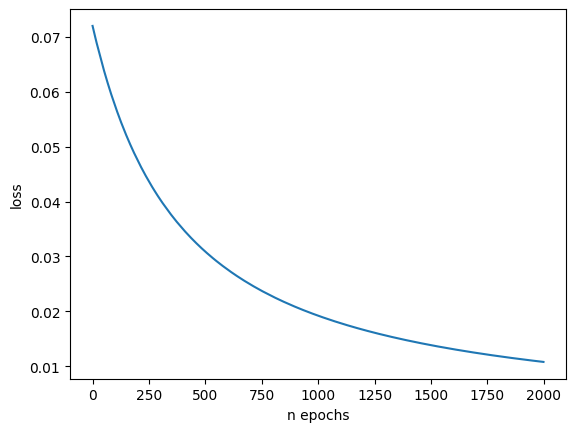

In [27]:
plt.figure()
plt.plot(history.history['loss'])
plt.xlabel('n epochs')
plt.ylabel('loss')

In [136]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import matplotlib.pyplot as plt

In [137]:


path_to_dataset = '/voting_complete.csv' # change the PATH
pd_dataset = pd.read_csv(path_to_dataset)

pd_dataset


,Unnamed: 0,Class Name,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,0,republican,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,2,democrat,?,y,y,?,y,y,n,n,n,n,y,n,y,y,n,n
3,3,democrat,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
4,4,democrat,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,430,republican,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
431,431,democrat,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y
432,432,republican,n,?,n,y,y,y,n,n,n,n,y,y,y,y,n,y
433,433,republican,n,n,n,y,y,y,?,?,?,?,n,y,y,y,n,y


In [138]:
def train_test_split(pd_data: pd.DataFrame, test_ratio: float = 0.2) -> tuple:
    pd_dataset = pd_data.copy()
    pd_dataset = pd_dataset[pd_dataset.columns[1:]]
    index = np.arange(len(pd_dataset))
    index = np.random.permutation(index)
    train_ammount = int(len(index)*test_ratio)
    train_ids = index[train_ammount:]
    test_ids = index[:train_ammount]

    train_dataset = pd_dataset[pd_dataset.index.isin(train_ids)].reset_index()
    test_dataset = pd_dataset[pd_dataset.index.isin(test_ids)].reset_index()

    train_dataset = train_dataset[train_dataset.columns[1:]]
    test_dataset = test_dataset[test_dataset.columns[1:]]

    return train_dataset[train_dataset.columns[1:]], train_dataset[train_dataset.columns[0]], test_dataset[test_dataset.columns[1:]], test_dataset[test_dataset.columns[0]]


In [139]:
x_train, y_train, x_test, y_test = train_test_split(pd_dataset)

In [140]:
x_train

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,n,y,n,y,y,y,n,n,n,y,?,y,y,y,n,y
1,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,?
2,n,y,y,n,?,y,n,n,n,n,y,n,y,n,n,y
3,y,y,y,n,y,y,n,n,n,n,y,?,y,y,y,y
4,n,y,y,n,y,y,n,n,n,n,n,n,y,y,y,y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,n,n,y,n,n,n,y,y,n,y,y,n,n,n,y,?
344,n,n,n,y,y,y,y,y,n,y,n,y,y,y,n,y
345,?,?,?,n,n,n,y,y,y,y,n,n,y,n,y,y
346,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y


In [141]:
y_train

,Class Name
0,republican
1,republican
2,democrat
3,democrat
4,democrat
...,...
343,democrat
344,republican
345,democrat
346,democrat


In [142]:

x = pd.get_dummies(x_train)
x

,handicapped-infants_?,handicapped-infants_n,handicapped-infants_y,water-project-cost-sharing_?,water-project-cost-sharing_n,water-project-cost-sharing_y,adoption-of-the-budget-resolution_?,adoption-of-the-budget-resolution_n,adoption-of-the-budget-resolution_y,physician-fee-freeze_?,...,superfund-right-to-sue_y,crime_?,crime_n,crime_y,duty-free-exports_?,duty-free-exports_n,duty-free-exports_y,export-administration-act-south-africa_?,export-administration-act-south-africa_n,export-administration-act-south-africa_y
0,False,True,False,False,False,True,False,True,False,False,...,True,False,False,True,False,True,False,False,False,True
1,False,True,False,False,False,True,False,True,False,False,...,True,False,False,True,False,True,False,True,False,False
2,False,True,False,False,False,True,False,False,True,False,...,True,False,True,False,False,True,False,False,False,True
3,False,False,True,False,False,True,False,False,True,False,...,True,False,False,True,False,False,True,False,False,True
4,False,True,False,False,False,True,False,False,True,False,...,True,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,False,True,False,False,True,False,False,False,True,False,...,False,False,True,False,False,False,True,True,False,False
344,False,True,False,False,True,False,False,True,False,False,...,True,False,False,True,False,True,False,False,False,True
345,True,False,False,True,False,False,True,False,False,False,...,True,False,True,False,False,False,True,False,False,True
346,False,True,False,False,True,False,False,False,True,False,...,False,False,True,False,False,True,False,False,False,True


In [143]:
y_train = y_train.replace('republican',1)
y = y_train.replace('democrat', 0)
y

/tmp/ipykernel_262/672634194.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y_train.replace('democrat', 0)


,Class Name
0,1
1,1
2,0
3,0
4,0
...,...
343,0
344,1
345,0
346,0


In [144]:
model2 = Sequential()
model2.add(Dense(2, input_dim=48, activation='sigmoid'))
model2.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [145]:
model2.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 2)              │            98 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [146]:
optimizer2 = tf.keras.optimizers.SGD(learning_rate=0.8)
model2.compile(loss='binary_crossentropy', optimizer=optimizer2, metrics=['accuracy'])



In [147]:
history2 = model2.fit(x, y, epochs=300, batch_size=50, validation_split=0.2)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6481 - loss: 0.6470 - val_accuracy: 0.8429 - val_loss: 0.5249
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9174 - loss: 0.4535 - val_accuracy: 0.8714 - val_loss: 0.4309
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9471 - loss: 0.3530 - val_accuracy: 0.8571 - val_loss: 0.3686
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9346 - loss: 0.2907 - val_accuracy: 0.8857 - val_loss: 0.3307
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9459 - loss: 0.2436 - val_accuracy: 0.8857 - val_loss: 0.2984
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9309 - loss: 0.2229 - val_accuracy: 0.9143 - val_loss: 0.2752
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9606 - loss: 0.1841 - val_accuracy: 0.9286 - val_loss: 0.2546
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9636 - loss: 0.1619 - val_accuracy: 0.9286 - val_loss:

In [148]:
X_test = pd.get_dummies(x_test)
y_test = y_test.replace(['republican', 'democrat'], [1,0])
X_test

/tmp/ipykernel_262/596178521.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_test = y_test.replace(['republican', 'democrat'], [1,0])


,handicapped-infants_?,handicapped-infants_n,handicapped-infants_y,water-project-cost-sharing_?,water-project-cost-sharing_n,water-project-cost-sharing_y,adoption-of-the-budget-resolution_?,adoption-of-the-budget-resolution_n,adoption-of-the-budget-resolution_y,physician-fee-freeze_?,...,superfund-right-to-sue_y,crime_?,crime_n,crime_y,duty-free-exports_?,duty-free-exports_n,duty-free-exports_y,export-administration-act-south-africa_?,export-administration-act-south-africa_n,export-administration-act-south-africa_y
0,True,False,False,False,False,True,False,False,True,True,...,True,False,False,True,False,True,False,False,True,False
1,False,True,False,False,False,True,False,True,False,False,...,True,False,False,True,True,False,False,True,False,False
2,False,True,False,False,False,True,False,True,False,False,...,True,True,False,False,False,True,False,True,False,False
3,False,False,True,False,True,False,False,False,True,False,...,False,False,True,False,False,False,True,True,False,False
4,False,False,True,False,True,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,False,False,True,False,True,False,False,False,True,False,...,False,False,True,False,False,False,True,False,False,True
83,False,False,True,False,True,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True
84,False,True,False,False,True,False,False,False,True,False,...,True,False,False,True,False,True,False,False,False,True
85,False,True,False,False,True,False,False,True,False,False,...,True,False,False,True,False,True,False,False,False,True


In [149]:
loss, accuracy = model2.evaluate(X_test, y_test)
print('Accuracy: {:.2f}'.format(accuracy*100))

loss

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9653 - loss: 0.1617
Accuracy: 95.40


0.21472983062267303

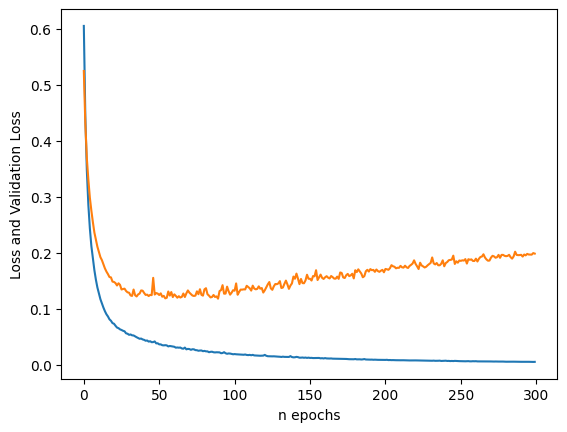

In [150]:
plt.figure()
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.xlabel('n epochs')
plt.ylabel('Loss and Validation Loss')
plt.show()

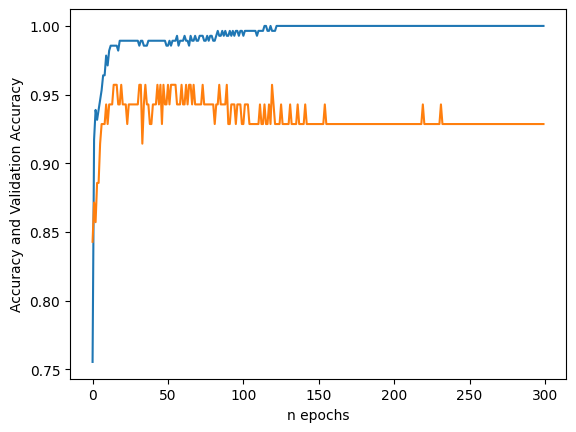

In [151]:
plt.figure()
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('n epochs')
plt.ylabel('Accuracy and Validation Accuracy')
plt.show()